# Pose estimation for isolated Poomsae athletes

Run this notebook after athlete tracking and isolation. It reads each normalized `crop.mp4`, estimates all 33 MediaPipe Pose landmarks per frame, and writes pose outputs beside the isolated video.

```text
data/processed/players/WP12/angles/45/pose/
├── keypoints.csv
├── features.csv
├── annotated.mp4
└── metadata.json
```

The batch is resumable: a video is skipped when all requested pose outputs already exist.

In [1]:
from dataclasses import asdict
import json
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Video, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from poomsae_scoring.scoring.pose_estimation import (
    PoseConfig,
    PoseEstimationPipeline,
    create_pose_estimator,
    discover_pose_videos,
    draw_mediapipe_pose,
    pose_output_is_complete,
)


## Configuration

`ANGLES_TO_PROCESS = None` processes every available view. Set it to `{"45"}` to process exactly the 54 videos from the 45-degree camera.

These are the same MediaPipe settings used in `front_athlete_preprocessing.ipynb`: video tracking mode, model complexity 2, and 0.5 detection/tracking confidence. MediaPipe processes frames sequentially so its temporal landmark tracker remains active.

In [2]:
PLAYERS_ROOT = PROJECT_ROOT / "data/processed/players"
ANGLES_TO_PROCESS = None  # Example for 54 videos: {"45"}
MODEL_COMPLEXITY = 2
MIN_DETECTION_CONFIDENCE = 0.5
MIN_TRACKING_CONFIDENCE = 0.5
KEYPOINT_CONFIDENCE = 0.25
OUTPUT_SIZE = 640
SMOOTH_LANDMARKS = True
SAVE_ANNOTATED_VIDEO = True
MAX_DURATION_SECONDS = None

config = PoseConfig(
    model_complexity=MODEL_COMPLEXITY,
    minimum_detection_confidence=MIN_DETECTION_CONFIDENCE,
    minimum_tracking_confidence=MIN_TRACKING_CONFIDENCE,
    keypoint_confidence=KEYPOINT_CONFIDENCE,
    output_size=OUTPUT_SIZE,
    smooth_landmarks=SMOOTH_LANDMARKS,
    save_annotated_video=SAVE_ANNOTATED_VIDEO,
    maximum_duration_seconds=MAX_DURATION_SECONDS,
)

assert PLAYERS_ROOT.is_dir(), f"Processed players directory does not exist: {PLAYERS_ROOT}"
print(f"Pose inputs: {PLAYERS_ROOT}")
print("Pose backend: MediaPipe Pose")
print(f"Model complexity: {MODEL_COMPLEXITY}")


Pose inputs: /home/nazi/Desktop/poomsae-scoring-system/data/processed/players
Pose backend: MediaPipe Pose
Model complexity: 2


## Discover isolated videos

The current dataset contains 54 players and up to three angles per player. This cell reports the exact number of available and pending videos before MediaPipe processing starts.

In [3]:
videos = discover_pose_videos(PLAYERS_ROOT, ANGLES_TO_PROCESS)
inventory = pd.DataFrame(
    [
        {
            "player_id": video.player_id,
            "angle": video.angle,
            "crop_path": str(video.path),
            "pose_complete": pose_output_is_complete(
                video,
                save_annotated_video=SAVE_ANNOTATED_VIDEO,
            ),
        }
        for video in videos
    ]
)

assert videos, "No crop.mp4 files were found. Run athlete isolation first."
print(f"Players found: {inventory['player_id'].nunique()}")
print(f"Pose input videos found: {len(inventory)}")
print(f"Already complete: {int(inventory['pose_complete'].sum())}")
print(f"Pending: {int((~inventory['pose_complete']).sum())}")
display(inventory.head(12))


Players found: 54
Pose input videos found: 162
Already complete: 105
Pending: 57


,player_id,angle,crop_path,pose_complete
0,WP1,0,/home/nazi/Desktop/poomsae-scoring-system/data...,True
1,WP1,45,/home/nazi/Desktop/poomsae-scoring-system/data...,True
2,WP1,135,/home/nazi/Desktop/poomsae-scoring-system/data...,True
3,WP2,0,/home/nazi/Desktop/poomsae-scoring-system/data...,True
4,WP2,45,/home/nazi/Desktop/poomsae-scoring-system/data...,True
5,WP2,135,/home/nazi/Desktop/poomsae-scoring-system/data...,True
6,WP3,0,/home/nazi/Desktop/poomsae-scoring-system/data...,True
7,WP3,45,/home/nazi/Desktop/poomsae-scoring-system/data...,True
8,WP3,135,/home/nazi/Desktop/poomsae-scoring-system/data...,True
9,WP4,0,/home/nazi/Desktop/poomsae-scoring-system/data...,True


## Initialize MediaPipe and preview one frame

This performs one pose prediction and displays the overlay. Confirm that the skeleton follows the isolated athlete before starting the full batch.

Pose backend: MediaPipe Pose (33 landmarks)


I0000 00:00:1786379557.408547    7478 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1786379557.411519    7671 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-2+deb13u1), renderer: Mesa Intel(R) Graphics (ADL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1786379557.510911    7656 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786379557.659678    7665 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786379557.777392    7666 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


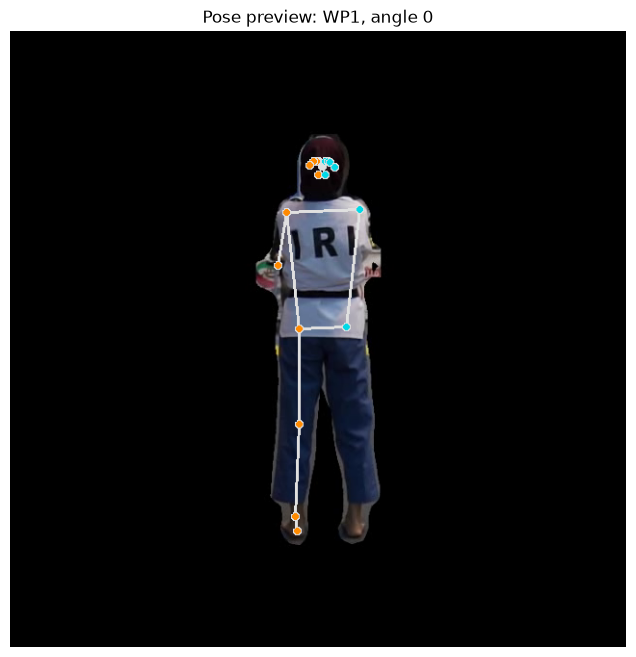

In [4]:
pipeline = PoseEstimationPipeline(config)
print("Pose backend: MediaPipe Pose (33 landmarks)")

preview_video = videos[0]
capture = cv2.VideoCapture(str(preview_video.path))
frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
capture.set(cv2.CAP_PROP_POS_FRAMES, max(0, frame_count // 2))
success, preview_frame = capture.read()
capture.release()
assert success, f"Could not read preview frame: {preview_video.path}"

if preview_frame.shape[:2] != (OUTPUT_SIZE, OUTPUT_SIZE):
    preview_frame = cv2.resize(preview_frame, (OUTPUT_SIZE, OUTPUT_SIZE))

with create_pose_estimator(config, pipeline.mediapipe) as preview_pose:
    preview_rgb = cv2.cvtColor(preview_frame, cv2.COLOR_BGR2RGB)
    preview_result = preview_pose.process(preview_rgb)

assert preview_result.pose_landmarks, "MediaPipe did not detect a pose in the preview frame."
preview_annotated = draw_mediapipe_pose(
    preview_frame,
    preview_result.pose_landmarks,
    pipeline.mediapipe,
)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(preview_annotated, cv2.COLOR_BGR2RGB))
plt.title(f"Pose preview: {preview_video.player_id}, angle {preview_video.angle}")
plt.axis("off")
plt.show()


## Run pose estimation

The cell processes all pending videos selected by `ANGLES_TO_PROCESS`. Completed outputs are skipped, so it is safe to stop the notebook and run the cell again later.

Set `PLAYERS_PER_BATCH` below 54 when you prefer smaller sessions. All available angles for each selected player are processed together.

In [7]:
RUN_BATCH = True
PLAYERS_PER_BATCH = 4

pending_videos = [
    video
    for video in videos
    if not pose_output_is_complete(
        video,
        save_annotated_video=SAVE_ANNOTATED_VIDEO,
    )
]
pending_player_ids = list(dict.fromkeys(video.player_id for video in pending_videos))
selected_player_ids = set(pending_player_ids[:PLAYERS_PER_BATCH])
selected_videos = [
    video for video in pending_videos if video.player_id in selected_player_ids
]

if RUN_BATCH and selected_videos:
    print(
        f"Processing {len(selected_videos)} videos for "
        f"{len(selected_player_ids)} players."
    )
    results = []
    for video in selected_videos:
        result = pipeline.process_video(video)
        results.append(result)
        print(
            f"Finished {result.player_id}-{result.angle}: "
            f"{result.frames_detected}/{result.frames_processed} frames detected "
            f"({result.detection_rate:.1%})"
        )

    results_table = pd.DataFrame([asdict(result) for result in results])
    display(results_table)
elif RUN_BATCH:
    print("All selected pose videos are already complete.")
else:
    print("Batch processing skipped. Set RUN_BATCH = True to run it.")


I0000 00:00:1786388525.153931    7478 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1786388525.155803   97506 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-2+deb13u1), renderer: Mesa Intel(R) Graphics (ADL GT2)


Processing 12 videos for 4 players.


MediaPipe pose WP51-0:   0%|          | 0/2367 [00:00<?, ?frame/s]W0000 00:00:1786388525.205975   97489 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786388525.275595   97500 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
MediaPipe pose WP51-0: 100%|██████████| 2367/2367 [02:02<00:00, 19.26frame/s]
I0000 00:00:1786388648.073693    7478 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1786388648.076210   98672 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-2+deb13u1), renderer: Mesa Intel(R) Graphics (ADL GT2)


Finished WP51-0: 2356/2367 frames detected (99.5%)


MediaPipe pose WP51-45:   0%|          | 0/2355 [00:00<?, ?frame/s]W0000 00:00:1786388648.136308   98652 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786388648.186610   98659 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
MediaPipe pose WP51-45: 100%|██████████| 2355/2355 [00:55<00:00, 42.07frame/s]
I0000 00:00:1786388704.073163    7478 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5


...

MediaPipe pose WP54-45:   0%|          | 0/2258 [00:00<?, ?frame/s]W0000 00:00:1786390026.199119  113415 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786390026.276432  113427 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
MediaPipe pose WP54-45: 100%|██████████| 2258/2258 [01:58<00:00, 19.12frame/s]
I0000 00:00:1786390144.258119    7478 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1786390144.259489  114611 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-2+deb13u1), renderer: Mesa Intel(R) Graphics (ADL GT2)


Finished WP54-45: 1996/2258 frames detected (88.4%)


MediaPipe pose WP54-135:   0%|          | 0/2254 [00:00<?, ?frame/s]W0000 00:00:1786390144.304891  114604 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786390144.379458  114601 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
MediaPipe pose WP54-135: 100%|██████████| 2254/2254 [02:07<00:00, 17.71frame/s]

Finished WP54-135: 2238/2254 frames detected (99.3%)


,player_id,angle,input_path,output_directory,width,height,fps,frames_processed,frames_detected,detection_rate,backend
0,WP51,0,/home/nazi/Desktop/poomsae-scoring-system/data...,/home/nazi/Desktop/poomsae-scoring-system/data...,640,640,50.0,2367,2356,0.995353,MediaPipe Pose
1,WP51,45,/home/nazi/Desktop/poomsae-scoring-system/data...,/home/nazi/Desktop/poomsae-scoring-system/data...,640,640,50.0,2355,568,0.241189,MediaPipe Pose
2,WP51,135,/home/nazi/Desktop/poomsae-scoring-system/data...,/home/nazi/Desktop/poomsae-scoring-system/data...,640,640,50.0,2353,2167,0.920952,MediaPipe Pose
3,WP52,0,/home/nazi/Desktop/poomsae-scoring-system/data...,/home/nazi/Desktop/poomsae-scoring-system/data...,640,640,50.0,2416,2388,0.988411,MediaPipe Pose
4,WP52,45,/home/nazi/Desktop/poomsae-scoring-system/data...,/home/nazi/Desktop/poomsae-scoring-system/data...,640,640,50.0,2403,2366,0.984603,MediaPipe Pose
5,WP52,135,/home/nazi/Desktop/poomsae-scoring-system/data...,/home/nazi/Desktop/poomsae-scoring-system/data...,640,640,50.0,2400,2398,0.999167,MediaPipe Pose
6,WP53,0,/home/nazi/Desktop/poomsae-scoring-system/data...,/home/nazi/Desktop/poomsae-scoring-system/data...,640,640,50.0,2610,2526,0.967816,MediaPipe Pose
7,WP53,45,/home/nazi/Desktop/poomsae-scoring-system/data...,/home/nazi/Desktop/poomsae-scoring-system/data...,640,640,50.0,2597,2545,0.979977,MediaPipe Pose
8,WP53,135,/home/nazi/Desktop/poomsae-scoring-system/data...,/home/nazi/Desktop/poomsae-scoring-system/data...,640,640,50.0,2618,2577,0.984339,MediaPipe Pose
9,WP54,0,/home/nazi/Desktop/poomsae-scoring-system/data...,/home/nazi/Desktop/poomsae-scoring-system/data...,640,640,50.0,2271,2244,0.988111,MediaPipe Pose


## Inspect one completed result

Change `RESULT_PLAYER` and `RESULT_ANGLE` to inspect another presentation. Low-confidence or missing keypoints remain explicit in the CSV instead of silently dropping frames.

In [6]:
RESULT_PLAYER = videos[0].player_id
RESULT_ANGLE = videos[0].angle
pose_directory = PLAYERS_ROOT / RESULT_PLAYER / "angles" / RESULT_ANGLE / "pose"
keypoints_path = pose_directory / "keypoints.csv"
features_path = pose_directory / "features.csv"
metadata_path = pose_directory / "metadata.json"
annotated_path = pose_directory / "annotated.mp4"

if metadata_path.is_file():
    with metadata_path.open(encoding="utf-8") as file:
        pose_metadata = json.load(file)
    keypoints = pd.read_csv(keypoints_path)
    features = pd.read_csv(features_path)
    display(pd.DataFrame([pose_metadata]))
    display(keypoints.head())
    display(features.head())
    if annotated_path.is_file():
        display(Video(str(annotated_path), width=600, embed=False))
else:
    print(f"No completed pose result exists yet: {pose_directory}")


,player_id,angle,input_path,output_directory,width,height,fps,frames_processed,frames_detected,detection_rate,...,source_frames,completed_full_video,model_complexity,minimum_detection_confidence,minimum_tracking_confidence,keypoint_confidence,smooth_landmarks,maximum_duration_seconds,keypoint_format,keypoint_names
0,WP1,45,/home/nazi/Desktop/poomsae-scoring-system/data...,/home/nazi/Desktop/poomsae-scoring-system/data...,640,640,50.0,2601,2596,0.998078,...,2601,True,2,0.5,0.5,0.25,True,None,MediaPipe Pose 33,"[nose, left_eye_inner, left_eye, left_eye_oute..."


,frame_index,time_seconds,status,nose_x,nose_y,nose_z,nose_confidence,left_eye_inner_x,left_eye_inner_y,left_eye_inner_z,...,right_heel_z,right_heel_confidence,left_foot_index_x,left_foot_index_y,left_foot_index_z,left_foot_index_confidence,right_foot_index_x,right_foot_index_y,right_foot_index_z,right_foot_index_confidence
0,0,0.00,detected,321.625595,145.529079,101.319914,0.999424,315.594177,139.137096,87.830439,...,78.449526,0.714129,319.023228,506.447830,174.255161,0.381451,339.801483,514.973679,39.915042,0.494737
1,1,0.02,detected,320.892448,145.742521,102.510347,0.999410,315.100613,139.148359,87.886429,...,89.051867,0.714970,316.159821,505.103188,193.343811,0.383983,339.337387,514.875183,43.983955,0.497815
2,2,0.04,detected,321.082840,145.946531,97.850132,0.999372,315.289268,139.215574,82.251644,...,84.221630,0.705765,316.056271,505.053558,189.171848,0.374491,339.294777,514.884567,37.045636,0.487785
3,3,0.06,detected,321.202087,145.956516,88.598166,0.999354,315.422935,139.216261,72.590456,...,84.214392,0.701211,315.989380,504.864235,188.763809,0.371694,339.260521,515.007820,37.267678,0.483055
4,4,0.08,detected,320.349312,146.093597,97.959318,0.999292,314.849701,139.283314,81.455774,...,56.133623,0.692842,314.270267,504.706955,151.838350,0.363047,338.895493,515.010757,13.251424,0.474275


,frame_index,time_seconds,status,motion_energy,left_elbow_angle,right_elbow_angle,left_knee_angle,right_knee_angle,support_knee_angle,kicking_knee_angle,...,shoulder_tilt_degrees,hip_tilt_degrees,stance_width_shoulders,balance_offset_shoulders,left_wrist_centerline,right_wrist_centerline,left_ankle_centerline,right_ankle_centerline,head_centerline,mean_keypoint_confidence
0,0,0.00,detected,NaN,NaN,173.373440,174.073134,171.925274,171.925274,174.073134,...,2.827008,3.191233,0.356554,0.011992,NaN,0.655626,-0.329508,-0.011992,0.141988,0.853072
1,1,0.02,detected,0.813157,NaN,174.595666,173.878624,174.040901,174.040901,173.878624,...,3.625274,3.732041,0.347519,0.003026,NaN,0.644839,-0.307568,0.003026,0.145921,0.847097
2,2,0.04,detected,0.351162,NaN,174.115062,173.891552,174.350167,174.350167,173.891552,...,4.231960,3.551448,0.351745,0.010252,NaN,0.647403,-0.304101,0.010252,0.156849,0.838924
3,3,0.06,detected,0.235762,NaN,173.838716,173.989909,174.472338,174.472338,173.989909,...,4.403344,3.029274,0.354679,0.015361,NaN,0.654571,-0.299606,0.015361,0.163676,0.833056
4,4,0.08,detected,0.688680,NaN,173.940539,173.759141,174.447644,174.447644,173.759141,...,4.607456,2.850152,0.352982,0.019092,NaN,0.638881,-0.293264,0.019092,0.159562,0.824389


## Dataset pose coverage

Run this after one or more batches to identify weak videos. Sort by detection rate and visually inspect the lowest values.

In [7]:
coverage_rows = []
for video in discover_pose_videos(PLAYERS_ROOT, ANGLES_TO_PROCESS):
    metadata_path = video.output_directory / "metadata.json"
    if not metadata_path.is_file():
        continue
    with metadata_path.open(encoding="utf-8") as file:
        metadata = json.load(file)
    coverage_rows.append(
        {
            "player_id": metadata["player_id"],
            "angle": metadata["angle"],
            "frames_processed": metadata["frames_processed"],
            "frames_detected": metadata["frames_detected"],
            "detection_rate": metadata["detection_rate"],
        }
    )

coverage = pd.DataFrame(coverage_rows)
if not coverage.empty:
    display(coverage.sort_values("detection_rate").reset_index(drop=True))
    display(coverage.groupby("angle")["detection_rate"].agg(["count", "mean", "min"]))
else:
    print("No pose metadata exists yet.")


,player_id,angle,frames_processed,frames_detected,detection_rate
0,WP2,45,2334,2101,0.900171
1,WP1,45,2601,2596,0.998078


,count,mean,min
angle,,,
45,2,0.949125,0.900171
